In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize
import statsmodels.stats.anova
from matplotlib.pyplot import subplots

In [2]:
auto = load_data("auto")

In [3]:
auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

In [4]:
auto['brand'] = auto['name'].str.split().str[0]

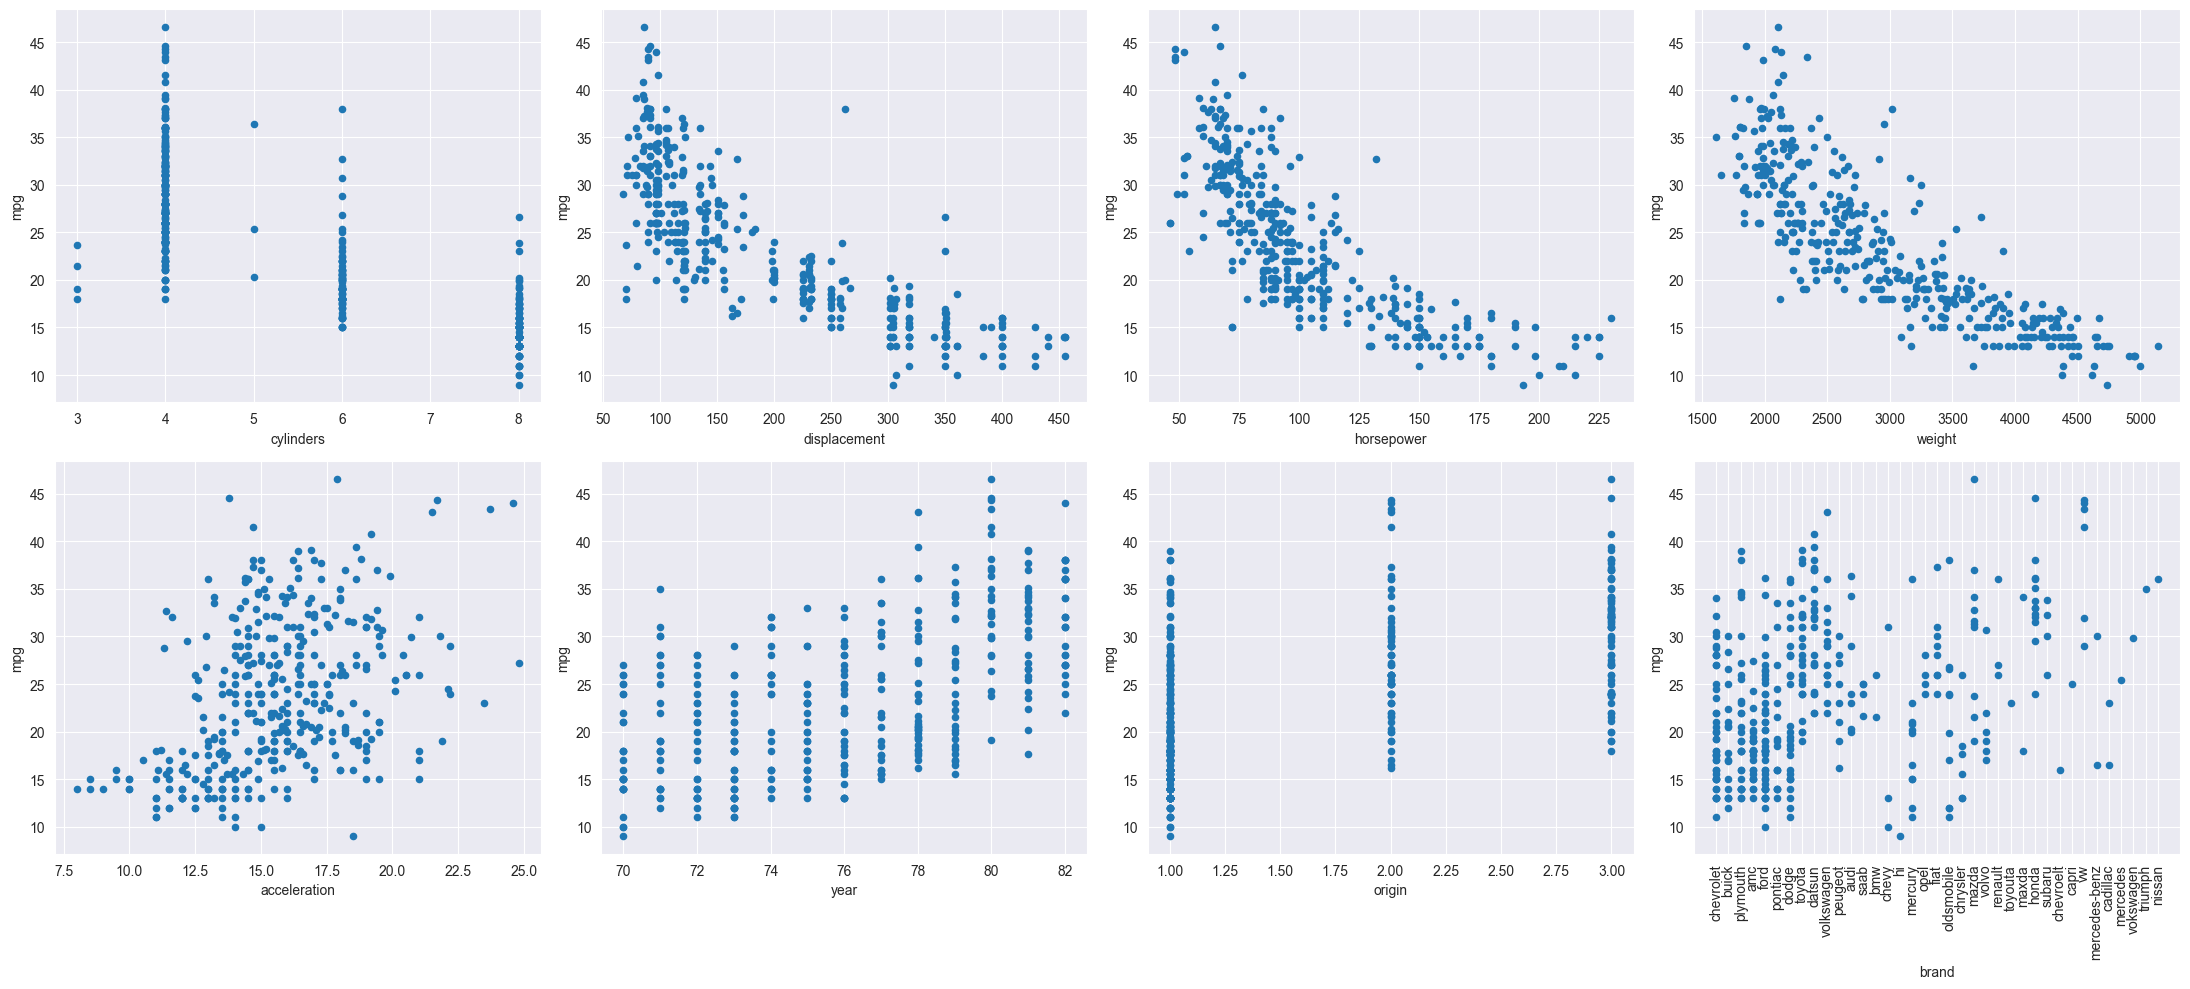

In [5]:
plt.figure(figsize=(22,10))
plt.subplot(241);auto.plot.scatter(y='mpg', x='cylinders', ax=plt.gca());
plt.subplot(242);auto.plot.scatter(y='mpg', x='displacement', ax=plt.gca());
plt.subplot(243);auto.plot.scatter(y='mpg', x='horsepower', ax=plt.gca());
plt.subplot(244);auto.plot.scatter(y='mpg', x='weight', ax=plt.gca());

plt.subplot(245);auto.plot.scatter(y='mpg', x='acceleration', ax=plt.gca());
plt.subplot(246);auto.plot.scatter(y='mpg', x='year', ax=plt.gca());
plt.subplot(247);auto.plot.scatter(y='mpg', x='origin', ax=plt.gca());
plt.subplot(248);auto.plot.scatter(y='mpg', x='brand', ax=plt.gca());plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [6]:
auto.corr(numeric_only=True) # from corr() works only if the data is in the form DataFrame

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


**_[cylinders, displacement, horsepower, weights]_** have the correlation among themselves

**_[acceleration, year, origin]_** are independent

In [7]:
y= auto['mpg']

design=MS(['cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'])
X = design.fit_transform(auto)

In [8]:
model = sm.OLS(y, X)
results = model.fit()

In [9]:
summarize(results) # remove - [cylinders, horsepower, acceleration]

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [10]:
from sklearn.preprocessing import StandardScaler
X1 = auto[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X1)

X_scaled_df = pd.DataFrame(X_scaled, columns=X1.columns)
X_scaled_with_const = sm.add_constant(X_scaled_df)
model1 = sm.OLS(y,X_scaled_with_const).fit()
summarize(model1)

# The scaled features stand on the metric of measurement. Whereas when the features are not scaled it gives the results in its own metrics of distribution.

# eg (unscaled): "For every 1 pound increase in weight, MPG decreases by 0.0065 units."

# eg (scaled): "For every 1 standard deviation increase in weight (~847 lbs), MPG decreases by 5.4921 units."

# if we see t-values of both (scaled and unscaled), the values are same.

,coef,std err,t,P>|t|
const,23.4459,0.168,139.498,0.000
cylinders,-0.8405,0.551,-1.526,0.128
displacement,2.0793,0.785,2.647,0.008
horsepower,-0.6516,0.530,-1.230,0.220
weight,-5.4921,0.553,-9.929,0.000
acceleration,0.2220,0.272,0.815,0.415
year,2.7621,0.188,14.729,0.000
origin,1.1473,0.224,5.127,0.000


In [11]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 07 Aug 2026   Prob (F-statistic):          2.04e-139
Time:                        15:44:47   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 07 Aug 2026   Prob (F-statistic):          2.04e-139
Time:                        15:44:47   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.4459      0.168    139.498      0.000      23.115      23.776
cylinders       -0.8405      0.551     -1.526      0.128      -1.923       0.242
displacement     2.0793      0.785      2.647      0.008       0.535       3.624
horsepower      -0.6516      0.530     -1.230      0.220      -1.694       0.390
weight          -5.4921      0.553     -9.929      0.000      -6.580      -4.404
acceleration     0.2220      0.272      0.815      0.415      -0.313       0.758
year             2.7621      0.188     14.729      0.000       2.393       3.131
origin           1.1473      0.224      5.127      0.000       0.707       1.587
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                         11.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
summarize(model1)

,coef,std err,t,P>|t|
const,23.4459,0.168,139.498,0.000
cylinders,-0.8405,0.551,-1.526,0.128
displacement,2.0793,0.785,2.647,0.008
horsepower,-0.6516,0.530,-1.230,0.220
weight,-5.4921,0.553,-9.929,0.000
acceleration,0.2220,0.272,0.815,0.415
year,2.7621,0.188,14.729,0.000
origin,1.1473,0.224,5.127,0.000


## Making a better model

In [14]:
X2 = auto[['displacement', 'weight', 'year', 'origin']]
X_scaled1 = scaler.fit_transform(X2)
X_scaled_df1 = pd.DataFrame(X_scaled1, columns=X2.columns)
X_scaled_df1.insert(0,"const",1)
model2 = sm.OLS(y,X_scaled_df1).fit()

In [15]:
summarize(model2)

,coef,std err,t,P>|t|
const,23.4459,0.169,138.735,0.000
displacement,0.5840,0.498,1.172,0.242
weight,-5.5779,0.473,-11.802,0.000
year,2.8380,0.183,15.486,0.000
origin,0.9864,0.215,4.593,0.000


In [16]:
X.columns

Index(['intercept', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
vif_values = [VIF(X,i) for i in range(1,X.shape[1])]
vif_df = pd.DataFrame({"vif": vif_values}, index=['cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'])

In [18]:
vif_df

,vif
cylinders,10.737535
displacement,21.836792
horsepower,9.943693
weight,10.831260
acceleration,2.625806
year,1.244952
origin,1.772386


In [19]:
summarize(model1)

,coef,std err,t,P>|t|
const,23.4459,0.168,139.498,0.000
cylinders,-0.8405,0.551,-1.526,0.128
displacement,2.0793,0.785,2.647,0.008
horsepower,-0.6516,0.530,-1.230,0.220
weight,-5.4921,0.553,-9.929,0.000
acceleration,0.2220,0.272,0.815,0.415
year,2.7621,0.188,14.729,0.000
origin,1.1473,0.224,5.127,0.000
